In [2]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from src.utils import load_table
from src.db.engine import engine


In [3]:
match_metrics_df = load_table("match_metrics", engine)

In [4]:
match_metrics_df

,match_id,bookmaker,season,league_division,home_norm_prob,away_norm_prob,draw_norm_prob,closing_home_norm_prob,closing_away_norm_prob,closing_draw_norm_prob,opening_overround,closing_overround,outcome,y_home,y_away,y_draw,brier_score_opening,brier_score_closing,log_loss_opening,log_loss_closing
0,1,market_average,21/22,L1,0.640001,0.147616,0.212383,0.670505,0.124297,0.205198,0.048657,0.050291,D,0,0,1,1.051731,1.096738,1.549363,1.583782
1,2,market_average,21/22,L1,0.712206,0.117677,0.170117,0.703727,0.119038,0.177235,0.047826,0.044857,D,0,0,1,1.209791,1.186344,1.771269,1.730279
2,3,market_average,21/22,L1,0.086810,0.751214,0.161976,0.106531,0.717683,0.175786,0.048173,0.047649,A,0,1,0,0.095667,0.121953,0.286065,0.331727
3,4,market_average,21/22,L1,0.471339,0.256632,0.272030,0.499124,0.233087,0.267789,0.050306,0.048958,D,0,0,1,0.817961,0.839588,1.301844,1.317558
4,5,market_average,21/22,L1,0.457337,0.262055,0.280608,0.369392,0.330913,0.299695,0.051237,0.049285,A,0,1,0,0.832460,0.673944,1.339200,1.105899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8380,1569,pinnacle,25/26,L1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,0,1,0,NaN,NaN,NaN,NaN
8381,1570,pinnacle,25/26,L1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,H,1,0,0,NaN,NaN,NaN,NaN
8382,1675,pinnacle,25/26,L1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,D,0,0,1,NaN,NaN,NaN,NaN
8383,1676,pinnacle,25/26,L1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,H,1,0,0,NaN,NaN,NaN,NaN


In [5]:
betwin = match_metrics_df.loc[
    match_metrics_df['bookmaker'] == 'betwin',
    ['closing_home_norm_prob', 'y_home']
]

In [6]:
betwin

,closing_home_norm_prob,y_home
172,NaN,1
238,NaN,0
239,NaN,1
307,NaN,1
308,NaN,1
...,...,...
6733,0.611129,0
6734,0.519343,1
6735,0.744503,0
6736,0.180180,1


In [7]:
pd.cut(betwin['closing_home_norm_prob'], 10)

172                NaN
238                NaN
239                NaN
307                NaN
308                NaN
             ...      
6733     (0.556, 0.64]
6734    (0.472, 0.556]
6735    (0.724, 0.809]
6736     (0.136, 0.22]
6737     (0.22, 0.304]
Name: closing_home_norm_prob, Length: 1677, dtype: category
Categories (10, interval[float64, right]): [(0.0509, 0.136] < (0.136, 0.22] < (0.22, 0.304] < (0.304, 0.388] ... (0.556, 0.64] < (0.64, 0.724] < (0.724, 0.809] < (0.809, 0.893]]

In [8]:
bins = pd.interval_range(start = 0, end = 1, periods = 10)

In [9]:
prob_distribution = pd.cut(betwin['closing_home_norm_prob'], bins)

In [10]:
hist = prob_distribution.sort_values().value_counts()

<BarContainer object of 10 artists>

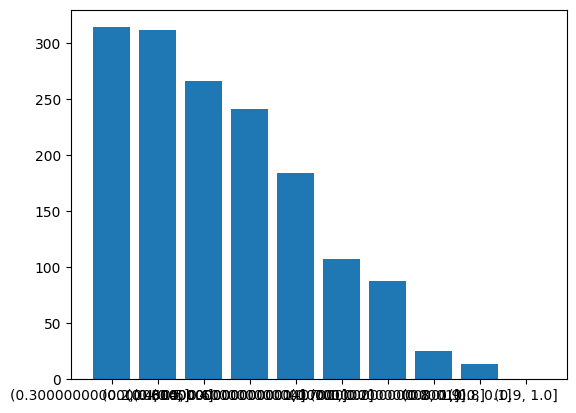

In [11]:
plt.bar(hist.index.astype(str), hist)

In [12]:
betwin

,closing_home_norm_prob,y_home
172,NaN,1
238,NaN,0
239,NaN,1
307,NaN,1
308,NaN,1
...,...,...
6733,0.611129,0
6734,0.519343,1
6735,0.744503,0
6736,0.180180,1


In [13]:
prob_dist = pd.cut(
    betwin['closing_home_norm_prob'],
    bins = np.linspace(0,1,11),
    include_lowest=True
)

In [27]:
prob_dist

172            NaN
238            NaN
239            NaN
307            NaN
308            NaN
           ...    
6733    (0.6, 0.7]
6734    (0.5, 0.6]
6735    (0.7, 0.8]
6736    (0.1, 0.2]
6737    (0.2, 0.3]
Name: closing_home_norm_prob, Length: 1677, dtype: category
Categories (10, interval[float64, right]): [(-0.001, 0.1] < (0.1, 0.2] < (0.2, 0.3] < (0.3, 0.4] ... (0.6, 0.7] < (0.7, 0.8] < (0.8, 0.9] < (0.9, 1.0]]

In [14]:
hist = prob_dist.value_counts()

In [31]:
hist

closing_home_norm_prob
(-0.001, 0.1]     14
(0.1, 0.2]       107
(0.2, 0.3]       266
(0.3, 0.4]       314
(0.4, 0.5]       312
(0.5, 0.6]       241
(0.6, 0.7]       184
(0.7, 0.8]        88
(0.8, 0.9]        25
(0.9, 1.0]         0
Name: count, dtype: int64

In [15]:
hist.index.astype(str).sort_values()

Index(['(-0.001, 0.1]', '(0.1, 0.2]', '(0.2, 0.3]', '(0.3, 0.4]', '(0.4, 0.5]',
       '(0.5, 0.6]', '(0.6, 0.7]', '(0.7, 0.8]', '(0.8, 0.9]', '(0.9, 1.0]'],
      dtype='str', name='closing_home_norm_prob')

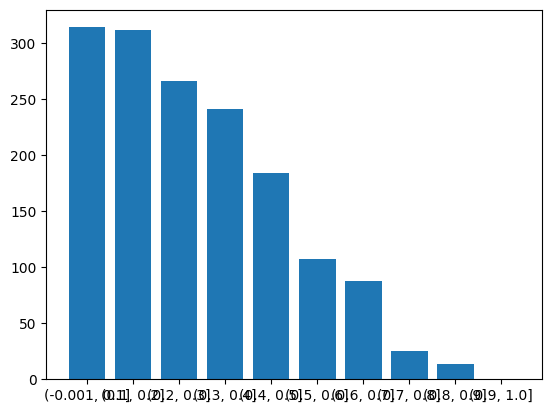

In [16]:
plt.bar(
    hist.index.astype(str).sort_values(),
    hist
)

plt.show()

In [17]:
hist 

closing_home_norm_prob
(0.3, 0.4]       314
(0.4, 0.5]       312
(0.2, 0.3]       266
(0.5, 0.6]       241
(0.6, 0.7]       184
(0.1, 0.2]       107
(0.7, 0.8]        88
(0.8, 0.9]        25
(-0.001, 0.1]     14
(0.9, 1.0]         0
Name: count, dtype: int64

In [18]:
hist = prob_dist.value_counts().sort_index()

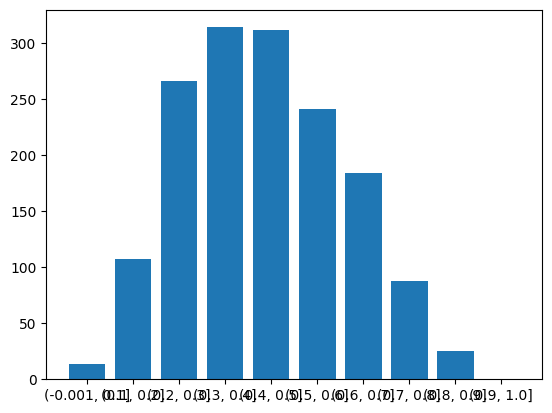

In [19]:
plt.bar(
    hist.index.astype(str),
    hist
)

plt.show()

In [20]:
prob_dist

172            NaN
238            NaN
239            NaN
307            NaN
308            NaN
           ...    
6733    (0.6, 0.7]
6734    (0.5, 0.6]
6735    (0.7, 0.8]
6736    (0.1, 0.2]
6737    (0.2, 0.3]
Name: closing_home_norm_prob, Length: 1677, dtype: category
Categories (10, interval[float64, right]): [(-0.001, 0.1] < (0.1, 0.2] < (0.2, 0.3] < (0.3, 0.4] ... (0.6, 0.7] < (0.7, 0.8] < (0.8, 0.9] < (0.9, 1.0]]

In [21]:
betwin['bins'] = prob_dist

In [22]:
betwin

,closing_home_norm_prob,y_home,bins
172,NaN,1,NaN
238,NaN,0,NaN
239,NaN,1,NaN
307,NaN,1,NaN
308,NaN,1,NaN
...,...,...,...
6733,0.611129,0,"(0.6, 0.7]"
6734,0.519343,1,"(0.5, 0.6]"
6735,0.744503,0,"(0.7, 0.8]"
6736,0.180180,1,"(0.1, 0.2]"


In [23]:
bins

IntervalIndex([                              (0.0, 0.1],
                                             (0.1, 0.2],
                             (0.2, 0.30000000000000004],
                             (0.30000000000000004, 0.4],
                                             (0.4, 0.5],
                              (0.5, 0.6000000000000001],
               (0.6000000000000001, 0.7000000000000001],
                              (0.7000000000000001, 0.8],
                                             (0.8, 0.9],
                                             (0.9, 1.0]],
              dtype='interval[float64, right]')

In [24]:
for bin in bins:
    print(bin)

(0.0, 0.1]
(0.1, 0.2]
(0.2, 0.30000000000000004]
(0.30000000000000004, 0.4]
(0.4, 0.5]
(0.5, 0.6000000000000001]
(0.6000000000000001, 0.7000000000000001]
(0.7000000000000001, 0.8]
(0.8, 0.9]
(0.9, 1.0]


In [25]:
betwin

,closing_home_norm_prob,y_home,bins
172,NaN,1,NaN
238,NaN,0,NaN
239,NaN,1,NaN
307,NaN,1,NaN
308,NaN,1,NaN
...,...,...,...
6733,0.611129,0,"(0.6, 0.7]"
6734,0.519343,1,"(0.5, 0.6]"
6735,0.744503,0,"(0.7, 0.8]"
6736,0.180180,1,"(0.1, 0.2]"


In [26]:
calibration = betwin.groupby('bins').agg(home_wins = ('y_home', 'sum'), matches_in_bin = ('', 'count'))

KeyError: "Label(s) [''] do not exist"

In [ ]:
calibration['freq'] = calibration['home_wins']/1677

In [ ]:
calibration

,home_wins,freq
bins,,
"(-0.001, 0.1]",0,0.000000
"(0.1, 0.2]",14,0.008348
"(0.2, 0.3]",65,0.038760
"(0.3, 0.4]",108,0.064401
"(0.4, 0.5]",140,0.083482
"(0.5, 0.6]",132,0.078712
"(0.6, 0.7]",127,0.075730
"(0.7, 0.8]",61,0.036374
"(0.8, 0.9]",22,0.013119


In [ ]:
betwin

,closing_home_norm_prob,y_home,bins
172,NaN,1,NaN
238,NaN,0,NaN
239,NaN,1,NaN
307,NaN,1,NaN
308,NaN,1,NaN
...,...,...,...
6733,0.611129,0,"(0.6, 0.7]"
6734,0.519343,1,"(0.5, 0.6]"
6735,0.744503,0,"(0.7, 0.8]"
6736,0.180180,1,"(0.1, 0.2]"


In [ ]:
calibration = betwin.groupby('bins').agg(
    nb_matches = ('y_home', 'count'),
    home_wins = ('y_home', 'sum')
)

In [ ]:
calibration

,nb_matches,home_wins
bins,,
"(-0.001, 0.1]",14,0
"(0.1, 0.2]",107,14
"(0.2, 0.3]",266,65
"(0.3, 0.4]",314,108
"(0.4, 0.5]",312,140
"(0.5, 0.6]",241,132
"(0.6, 0.7]",184,127
"(0.7, 0.8]",88,61
"(0.8, 0.9]",25,22


In [ ]:
calibration['freq'] = (calibration['home_wins']/calibration['nb_matches'])

In [ ]:
calibration

,nb_matches,home_wins,freq
bins,,,
"(-0.001, 0.1]",14,0,0.000000
"(0.1, 0.2]",107,14,0.130841
"(0.2, 0.3]",266,65,0.244361
"(0.3, 0.4]",314,108,0.343949
"(0.4, 0.5]",312,140,0.448718
"(0.5, 0.6]",241,132,0.547718
"(0.6, 0.7]",184,127,0.690217
"(0.7, 0.8]",88,61,0.693182
"(0.8, 0.9]",25,22,0.880000


In [ ]:
calibration = betwin.groupby("bins").agg(
    nb_matches=("y_home", "count"),
    home_wins=("y_home", "sum"),
    mean_pred=("closing_home_norm_prob", "mean")
)

calibration["observed_freq"] = (
    calibration["home_wins"] / calibration["nb_matches"]
)

In [ ]:
calibration

,nb_matches,home_wins,mean_pred,observed_freq
bins,,,,
"(-0.001, 0.1]",14,0,0.083402,0.000000
"(0.1, 0.2]",107,14,0.161339,0.130841
"(0.2, 0.3]",266,65,0.253048,0.244361
"(0.3, 0.4]",314,108,0.352020,0.343949
"(0.4, 0.5]",312,140,0.449439,0.448718
"(0.5, 0.6]",241,132,0.544670,0.547718
"(0.6, 0.7]",184,127,0.645369,0.690217
"(0.7, 0.8]",88,61,0.738989,0.693182
"(0.8, 0.9]",25,22,0.840641,0.880000


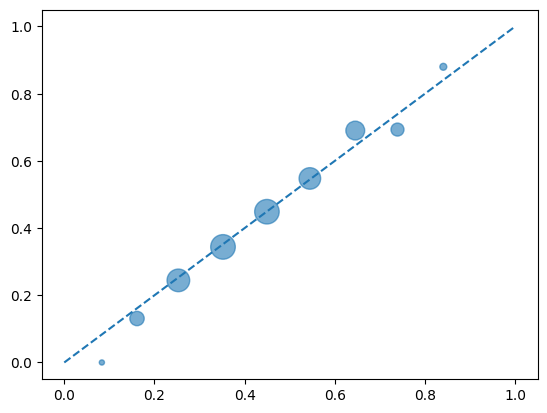

In [ ]:
plt.scatter(
    calibration["mean_pred"],
    calibration["observed_freq"],
    s=calibration["nb_matches"],
    alpha=0.6
)

plt.plot([0,1],[0,1],"--")